In [ ]:
! pip install spacy

In [10]:
import os
import csv
import spacy
class Corpus(object):
  def __init__(self,filename):
    self.filename = filename
    self.nlp=spacy.blank("en")
  def __iter__(self):
    with open(self.filename,"r") as f:
      reader=csv.reader(f,delimiter=",")
      for _,abstract in reader:
        tokens=[t.text.lower() for t in self.nlp.tokenizer(abstract)]
        yield tokens
documents=Corpus("/content/arxiv.csv")
documents = list(documents)
documents[:10]
#this reads the entire dataset and with the help of nlp steps it converts the dataset into tokens for each words

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [11]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 53.9 MB/s eta 0:00:00


In [12]:
import gensim

model = gensim.models.Word2Vec(documents, min_count=100, window=5, vector_size=100)
#it is used for embeddings vectorization

In [14]:
model.wv["nlp"]

array([ 0.39965725, -0.5832637 ,  2.7741334 , -0.47220156,  1.9396881 ,
       -1.265516  ,  2.4703796 , -0.02210116,  0.24494183,  2.3446405 ,
       -0.19994022, -1.0847293 ,  0.9531067 ,  0.372694  , -0.53944296,
        0.13834845, -1.9562446 ,  2.1898603 ,  1.2314087 ,  1.7022748 ,
        0.32302806, -0.301492  , -0.20473251,  0.10218742, -2.3990722 ,
       -0.9737901 ,  1.1166775 ,  2.1937528 ,  4.427538  , -0.01653227,
        1.2001419 , -0.39986292, -0.4253759 ,  0.5782574 , -0.5093762 ,
       -2.1555984 ,  0.47412738, -4.317252  , -0.42616582,  1.5620972 ,
       -1.5409164 , -1.5235208 ,  2.9528413 ,  0.09558726, -2.1921718 ,
        1.8250686 ,  1.5203724 ,  1.1045685 , -0.3518179 , -1.2842654 ,
        1.4305352 ,  0.54214823, -0.9442397 , -1.1901836 ,  1.7027296 ,
        0.55353236, -0.04631621,  0.54534537,  3.5784128 , -1.8274354 ,
       -0.52121204,  2.2130935 , -0.50239426, -0.41940498,  0.42025998,
        0.21129172, -1.094884  , -1.0824636 ,  0.52482367, -0.65

In [16]:
print(model.wv.similarity("nmt","smt"))
print(model.wv.similarity("nmt","ner"))
#for the 2 words it finds the cosine similarity and returns the similarity value with the help of individual vectors.If distance between vectors is less ,similarity is more

0.673143
0.40817466


In [17]:
model.wv.similar_by_word("bert", topn = 10)
#it displays the top 10 similar words for the word "bert"

[('roberta', 0.7938129901885986),
 ('transformer', 0.7758763432502747),
 ('transformers', 0.7401574850082397),
 ('elmo', 0.7374995350837708),
 ('pretrained', 0.7051609754562378),
 ('mbert', 0.6809835433959961),
 ('xlm', 0.6571488380432129),
 ('xlnet', 0.651272177696228),
 ('gpt-2', 0.6502277851104736),
 ('lstm', 0.6385355591773987)]

In [18]:
model.wv.most_similar(positive=["transformer", "lstm"], negative=["bert"])
#it displays the similar words for "transformmer" and "lstm" and dissimilar to "bert"

[('rnn', 0.8359208703041077),
 ('gru', 0.7959697246551514),
 ('recurrent', 0.7412649989128113),
 ('gated', 0.7021362781524658),
 ('directional', 0.6913071870803833),
 ('bilstm', 0.6886324882507324),
 ('convolution', 0.6880263090133667),
 ('attentional', 0.6826444268226624),
 ('lstms', 0.6496559977531433),
 ('convolutional', 0.6476320624351501)]

In [19]:
model.wv.most_similar(positive=["tree"], topn=10)

[('trees', 0.7692778706550598),
 ('constituency', 0.703361988067627),
 ('parse', 0.671904444694519),
 ('recursive', 0.6640782356262207),
 ('constituent', 0.6418247222900391),
 ('syntax', 0.6230061054229736),
 ('grammars', 0.6176633238792419),
 ('dependency', 0.6172267198562622),
 ('parser', 0.6066371202468872),
 ('path', 0.59976726770401)]

In [20]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split()))
print(model.wv.doesnt_match("bert word2vec gpt-2 roberta xlnet".split()))
print(model.wv.doesnt_match("word2vec bert glove fasttext elmo".split()))
#for this sentence it calculates an average vector and compare with the each word vector and returns the more distance word(doesnot match)

svm
word2vec
bert


In [23]:
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word = "bert"
selected_words = [w[0] for w in model.wv.most_similar(positive=[target_word], topn=200)] + [target_word]
embeddings = [model.wv[w] for w in selected_words] + model.wv["bert"]

mapped_embeddings = TSNE(n_components=2, metric='cosine', init='pca').fit_transform(embeddings)

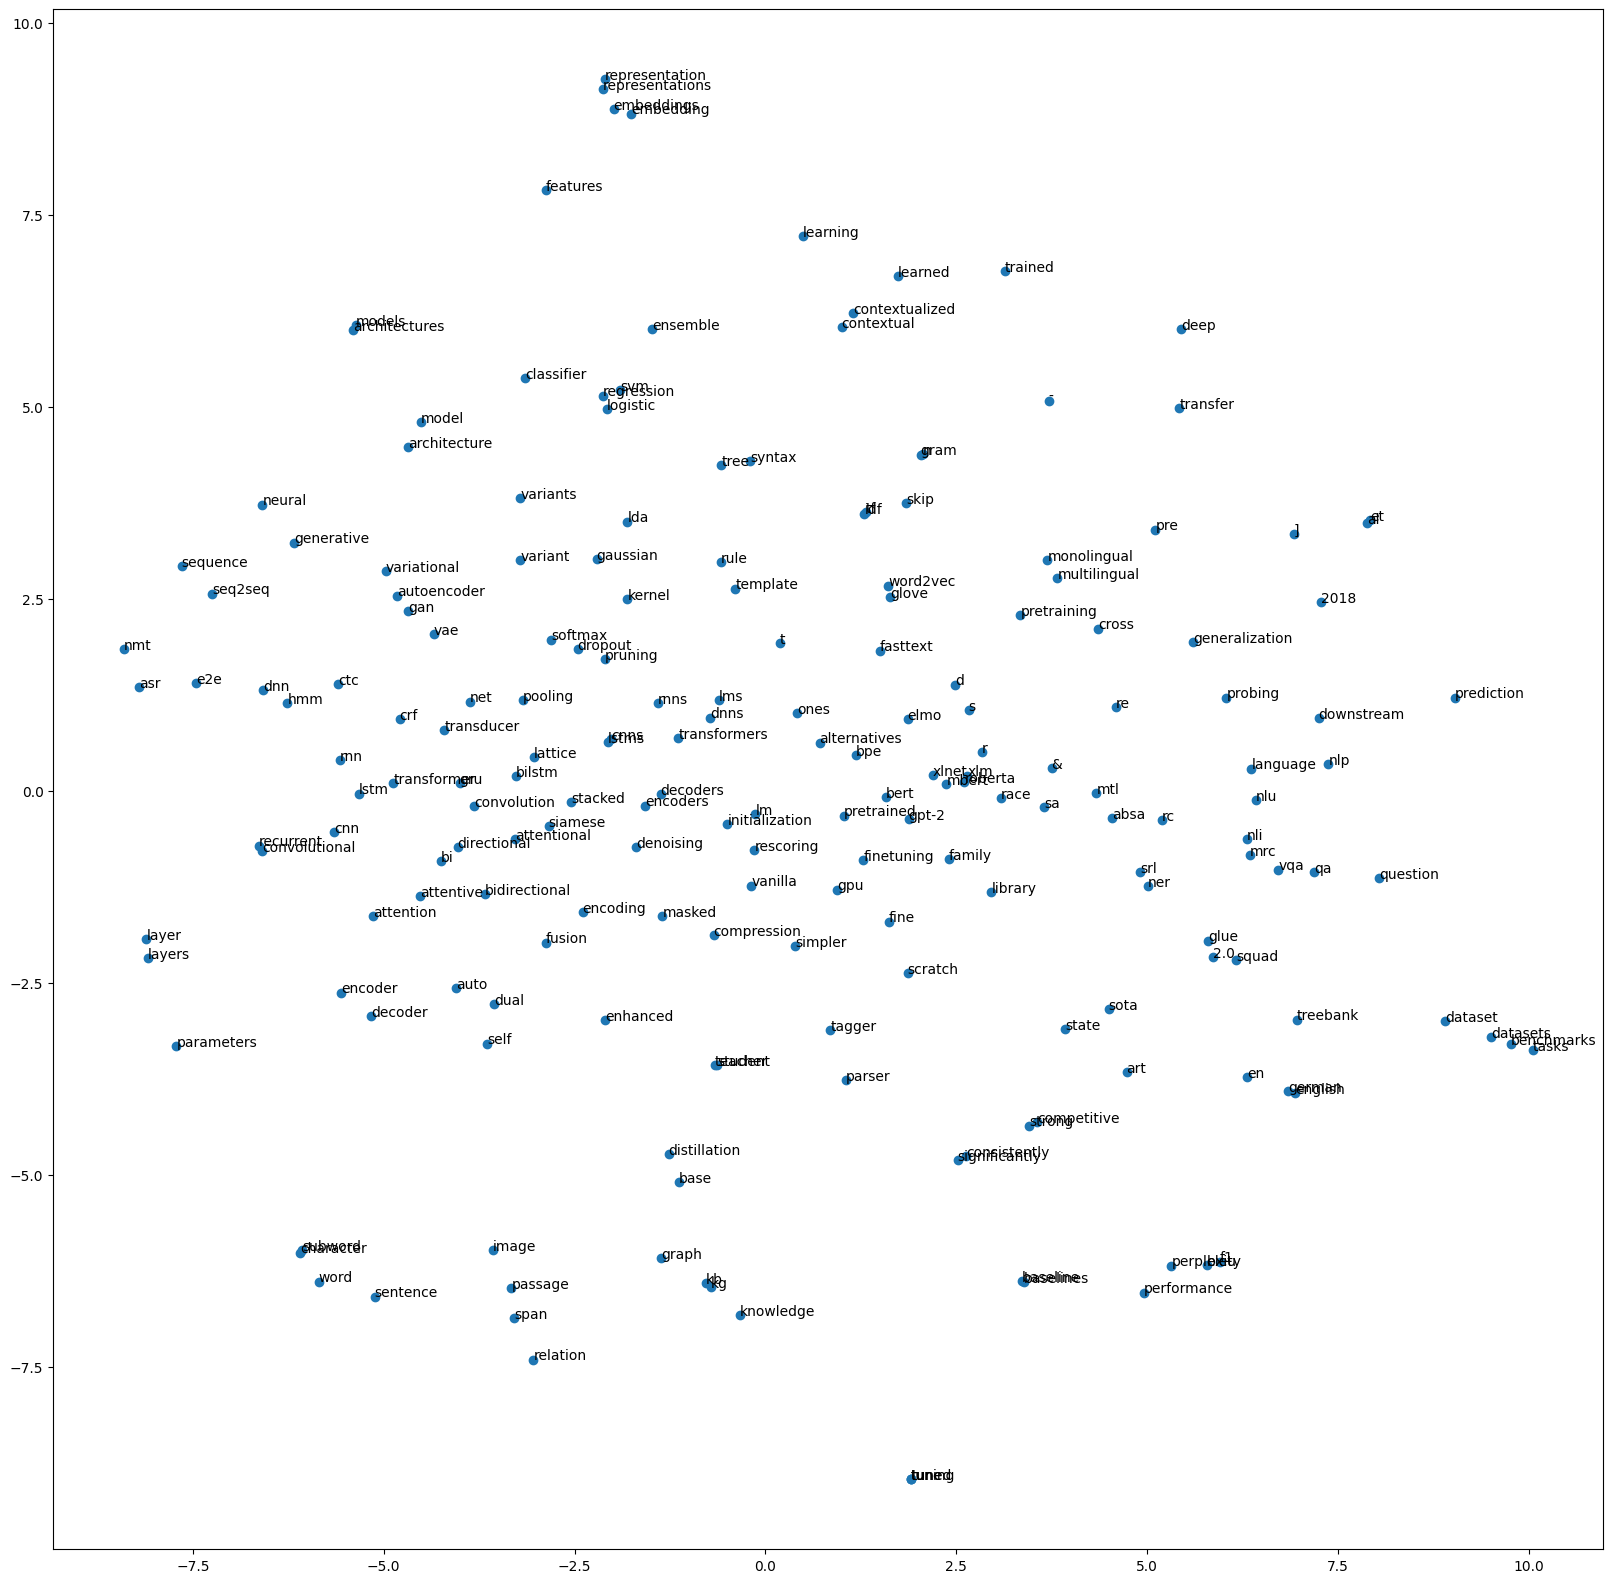

In [24]:
plt.figure(figsize=(20,20))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)
for i,txt in enumerate(selected_words):
  plt.annotate(txt,(x[i],y[i]))